In [247]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shaunthesheep/microsoft-catsvsdogs-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'microsoft-catsvsdogs-dataset' dataset.
Path to dataset files: /kaggle/input/microsoft-catsvsdogs-dataset


In [248]:
import os

os.listdir(path)

['PetImages', 'readme[1].txt', 'MSR-LA - 3467.docx']

In [249]:
dataset_path = os.path.join(path, "PetImages")

print(os.listdir(dataset_path))

['Dog', 'Cat']


In [250]:
dog_dataset = os.path.join(dataset_path, "Dog")
cat_dataset = os.path.join(dataset_path, "Cat")

In [251]:
import pandas as pd
import os



data = []

# Cat Images
for img in os.listdir(cat_dataset):
    data.append({
        "image_path": os.path.join(cat_dataset, img),
        "label": 0   # cat
    })

# Dogs Images
for img in os.listdir(dog_dataset):
    data.append({
        "image_path": os.path.join(dog_dataset, img),
        "label": 1   # dog
    })

df = pd.DataFrame(data)

df.head()

,image_path,label
0,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
1,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
2,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
3,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0
4,/kaggle/input/microsoft-catsvsdogs-dataset/Pet...,0


In [252]:
# Shuffle
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

In [253]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25002 entries, 0 to 25001
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  25002 non-null  object
 1   label       25002 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 390.8+ KB


In [254]:
df['label'].value_counts()

,count
label,
0,12501
1,12501


# Display a Photo

(np.float64(-0.5), np.float64(328.5), np.float64(449.5), np.float64(-0.5))

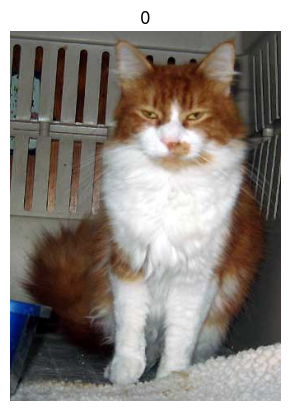

In [255]:
!pip install opencv-python
import cv2
import matplotlib.pyplot as plt

img = cv2.imread(df.iloc[0]["image_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(df.iloc[0]["label"])
plt.axis("off")

(np.float64(-0.5), np.float64(372.5), np.float64(340.5), np.float64(-0.5))

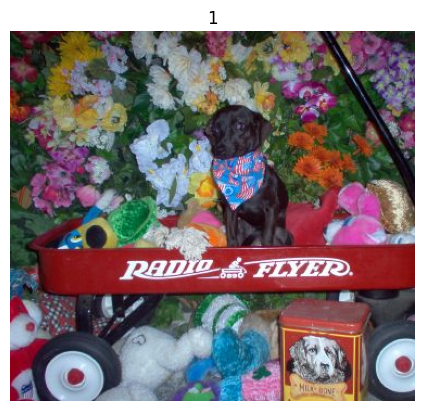

In [256]:
img = cv2.imread(df.iloc[4]["image_path"])
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.title(df.iloc[4]["label"])
plt.axis("off")

# split the feature and label

In [257]:
import numpy as np
import cv2

X = []
y = []

for index, row in df.iterrows():

    img = cv2.imread(row["image_path"])

    if img is None:
        continue

    img = cv2.resize(img,(128,128))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    X.append(img)
    y.append(row["label"])

X = np.array(X)
y = np.array(y)

print(X.shape)
print(y.shape)

(24997, 128, 128, 3)
(24997,)


(np.float64(-0.5), np.float64(127.5), np.float64(127.5), np.float64(-0.5))

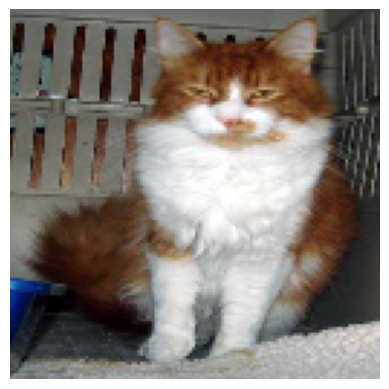

In [258]:
plt.imshow(X[0])
plt.axis("off")

# Train and Test split

In [259]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

In [260]:
!pip install tensorflow
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=32
)




In [261]:
val_datagen = ImageDataGenerator(rescale=1./255)

val_generator = val_datagen.flow(
    X_test,
    y_test,
    batch_size=32
)

In [262]:
from tensorflow.keras import layers, models

model = models.Sequential([

layers.Conv2D(32,(3,3),activation='relu',input_shape=(128,128,3)),
layers.BatchNormalization(),
layers.MaxPooling2D(2,2),

layers.Conv2D(64,(3,3),activation='relu'),
layers.BatchNormalization(),
layers.MaxPooling2D(2,2),

layers.Conv2D(128,(3,3),activation='relu'),
layers.BatchNormalization(),
layers.MaxPooling2D(2,2),

layers.Conv2D(256,(3,3),activation='relu'),
layers.MaxPooling2D(2,2),

layers.Flatten(),

layers.Dense(256,activation='relu'),
layers.Dropout(0.7),

layers.Dense(1,activation='sigmoid')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [263]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [264]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [265]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

In [266]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(X_train) // 32,
    epochs=20,
    validation_data=val_generator,
    callbacks=[early_stop, checkpoint]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step - accuracy: 0.6000 - loss: 1.0479
Epoch 1: val_loss improved from inf to 0.76606, saving model to best_model.keras
585/585 ━━━━━━━━━━━━━━━━━━━━ 79s 123ms/step - accuracy: 0.6001 - loss: 1.0473 - val_accuracy: 0.6181 - val_loss: 0.7661
Epoch 2/20
  1/585 ━━━━━━━━━━━━━━━━━━━━ 13s 23ms/step - accuracy: 0.7500 - loss: 0.7005

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.76606 to 0.69842, saving model to best_model.keras
585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7500 - loss: 0.7005 - val_accuracy: 0.6485 - val_loss: 0.6984
Epoch 3/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step - accuracy: 0.7255 - loss: 0.5560
Epoch 3: val_loss improved from 0.69842 to 0.56259, saving model to best_model.keras
585/585 ━━━━━━━━━━━━━━━━━━━━ 68s 116ms/step - accuracy: 0.7255 - loss: 0.5560 - val_accuracy: 0.7274 - val_loss: 0.5626
Epoch 4/20
  1/585 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.8125 - loss: 0.3660
Epoch 4: val_loss did not improve from 0.56259
585/585 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8125 - loss: 0.3660 - val_accuracy: 0.7258 - val_loss: 0.5708
Epoch 5/20
585/585 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step - accuracy: 0.7749 - loss: 0.4784
Epoch 5: val_loss did not improve from 0.56259
585/585 ━━━━━━━━━━━━━━━━━━━━ 70s 119ms/step - accuracy: 0.7749 - loss: 0.4784 - val_accuracy: 0.7400 - val_loss: 0.57

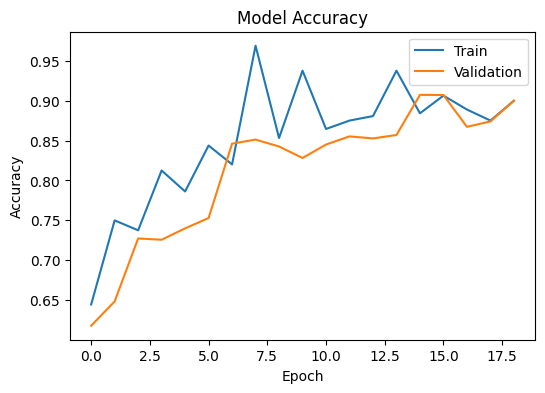

In [280]:
plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

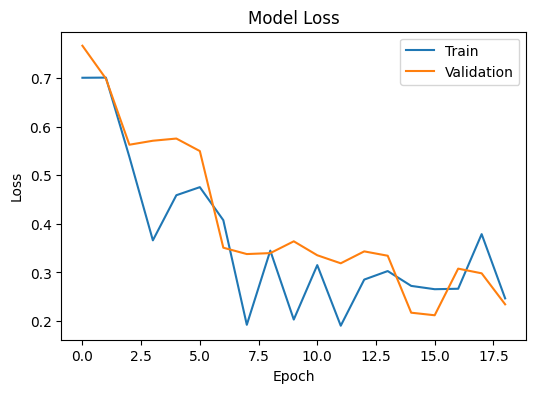

In [281]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(["Train","Validation"])

plt.show()

# Make it again just to make the shuffle False

In [276]:
val_generator = val_datagen.flow(
    X_test,
    y_test,
    batch_size=32,
    shuffle=False
)

In [277]:
pred = model.predict(val_generator)

pred = (pred > 0.5).astype(int)

 13/196 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


196/196 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step


In [278]:
from sklearn.metrics import classification_report, confusion_matrix

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.90      0.91      0.91      3125
           1       0.91      0.90      0.91      3125

    accuracy                           0.91      6250
   macro avg       0.91      0.91      0.91      6250
weighted avg       0.91      0.91      0.91      6250



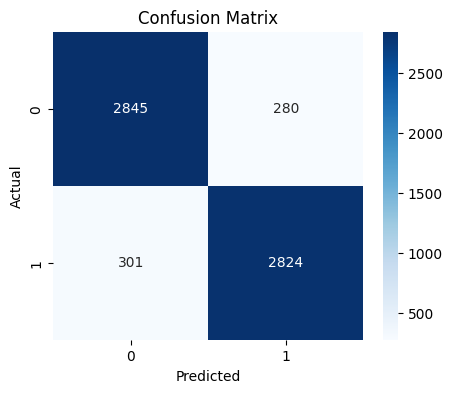

In [282]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

In [283]:
model.save("cats_dogs_cnn.keras")

In [284]:
from google.colab import files
files.download("cats_dogs_cnn.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>